# Regression Phase 2 - Common Experimental Protocol

**Problem:** Estimate hourly gas-turbine energy yield (`TEY`, MWh) from ambient and contemporaneous operating measurements.

**Phase boundary:** This notebook establishes the Review 1 dataset audit, EDA, cleaning decisions, feature engineering, chronological split, and leakage-safe preprocessing contract. Training and comparing the ten required regression algorithms belongs to Phase 3.

**Primary source:** [UCI Gas Turbine CO and NOx Emission Data Set](https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set), DOI [10.24432/C5WC95](https://doi.org/10.24432/C5WC95), CC BY 4.0.

> **Team verification gate:** Generative AI assisted with notebook scaffolding. Before evaluation, the team must rerun every cell, verify each observation against the visible output, and rewrite any interpretation that does not match its own understanding.

## 1. Reproducible setup

In [1]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_repo_root() -> Path:
    candidates = (Path.cwd(), *Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "requirements.txt").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the capstone repository.")

ROOT = find_repo_root()
print("Repository root detected.")
print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | scikit-learn: {sklearn.__version__}")

Repository root detected.
Python: 3.13.14
pandas: 3.0.6 | scikit-learn: 1.9.1


## 2. Data loading and modeling boundary

The five official yearly files are loaded in chronological order. The source year and row number are retained for audit and splitting only. `CO` and `NOX` are emission outcomes, so they are excluded from the predictor set. `year` and `source_row` are audit fields rather than model inputs.

In [2]:
DATA_DIR = ROOT / "data" / "raw" / "gas_turbine"
files = sorted(DATA_DIR.glob("gt_*.csv"))
if len(files) != 5:
    raise FileNotFoundError(
        "Expected five gas-turbine CSV files. Run: python data/download_datasets.py"
    )

frames = []
for path in files:
    frame = pd.read_csv(path)
    frame["year"] = int(path.stem.split("_")[1])
    frame["source_row"] = np.arange(len(frame))
    frames.append(frame)

raw = pd.concat(frames, ignore_index=True)
RAW_FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "CDP"]
TARGET = "TEY"
EXCLUDED_OUTCOMES = ["CO", "NOX"]

print(f"Files: {[path.name for path in files]}")
print(f"Raw shape: {raw.shape}")
display(raw.head())

Files: ['gt_2011.csv', 'gt_2012.csv', 'gt_2013.csv', 'gt_2014.csv', 'gt_2015.csv']
Raw shape: (36733, 13)


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,year,source_row
0,4.5878,"1,018.7000",83.6750,3.5758,23.9790,"1,086.2000",549.8300,134.6700,11.8980,0.3266,81.9520,2011,0
1,4.2932,"1,018.3000",84.2350,3.5709,23.9510,"1,086.1000",550.0500,134.6700,11.8920,0.4478,82.3770,2011,1
2,3.9045,"1,018.4000",84.8580,3.5828,23.9900,"1,086.5000",550.1900,135.1000,12.0420,0.4514,83.7760,2011,2
3,3.7436,"1,018.3000",85.4340,3.5808,23.9110,"1,086.5000",550.1700,135.0300,11.9900,0.2311,82.5050,2011,3
4,3.7516,"1,017.8000",85.1820,3.5781,23.9170,"1,085.9000",550.0000,134.6700,11.9100,0.2675,82.0280,2011,4


**Observation:** The files expose eleven measured columns; the notebook adds two audit columns. Only the eight declared ambient/operating variables are eligible predictors. This explicit allowlist prevents emission outcomes and time identifiers from entering a model accidentally.

## 3. Dataset audit

In [3]:
audit = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "missing": raw.isna().sum(),
        "unique": raw.nunique(dropna=False),
        "minimum": raw.select_dtypes(include=np.number).min(),
        "maximum": raw.select_dtypes(include=np.number).max(),
    }
)
display(audit)

duplicate_subset = RAW_FEATURES + [TARGET]
duplicate_rows = raw.duplicated(subset=duplicate_subset, keep=False)
duplicate_extras = raw.duplicated(subset=duplicate_subset, keep="first")
print(f"Missing values in complete table: {int(raw.isna().sum().sum())}")
print(f"Rows participating in duplicate groups: {int(duplicate_rows.sum())}")
print(f"Extra duplicate rows: {int(duplicate_extras.sum())}")
display(
    raw.loc[
        duplicate_rows,
        RAW_FEATURES + [TARGET, "CO", "NOX", "year", "source_row"],
    ].sort_values(RAW_FEATURES + [TARGET])
)

,dtype,missing,unique,minimum,maximum
AT,float64,0,22523,-6.2348,37.1030
AP,float64,0,791,985.8500,"1,036.6000"
AH,float64,0,25708,24.0850,100.2000
AFDP,float64,0,20495,2.0874,7.6106
GTEP,float64,0,12967,17.6980,40.7160
TIT,float64,0,799,"1,000.8000","1,100.9000"
TAT,float64,0,2769,511.0400,550.6100
TEY,float64,0,6236,100.0200,179.5000
CDP,float64,0,4447,9.8518,15.1590
CO,float64,0,26185,0.0004,44.1030


Missing values in complete table: 0
Rows participating in duplicate groups: 9
Extra duplicate rows: 7


,AT,AP,AH,AFDP,GTEP,TIT,TAT,CDP,TEY,CO,NOX,year,source_row
26398,23.1560,"1,004.2000",95.9380,4.0547,24.6720,"1,076.6000",549.8700,11.8350,127.0100,1.7056,47.3520,2014,4207
26399,23.1560,"1,004.2000",95.9380,4.0547,24.6720,"1,076.6000",549.8700,11.8350,127.0100,1.7056,47.3520,2014,4208
26400,23.1560,"1,004.2000",95.9380,4.0547,24.6720,"1,076.6000",549.8700,11.8350,127.0100,1.7056,47.3520,2014,4209
26401,23.1560,"1,004.2000",95.9380,4.0547,24.6720,"1,076.6000",549.8700,11.8350,127.0100,1.7056,47.3520,2014,4210
26402,23.1560,"1,004.2000",95.9380,4.0547,24.6720,"1,076.6000",549.8700,11.8350,127.0100,1.7056,47.3520,2014,4211
27388,26.0670,"1,008.3000",87.3280,5.0703,29.9840,"1,099.1000",546.7800,13.0380,146.1400,1.3163,52.5640,2014,5197
27389,26.0670,"1,008.3000",87.3280,5.0703,29.9840,"1,099.1000",546.7800,13.0380,146.1400,1.3163,52.5640,2014,5198
27390,26.0670,"1,008.3000",87.3280,5.0703,29.9840,"1,099.1000",546.7800,13.0380,146.1400,1.3163,52.5640,2014,5199
27391,26.0670,"1,008.3000",87.3280,5.0703,29.9840,"1,099.1000",546.7800,13.0380,146.1400,1.3163,52.5640,2014,5200


**Observation:** There are no missing values. Nine rows participate in two repeated groups, creating seven extra records. They are consecutive, fully identical sensor records within 2014, including `CO` and `NOX`; retaining them would give those operating states repeated weight. Phase 2 therefore keeps the first observation from each group and removes the seven extras while preserving chronological order.

In [4]:
target_summary = raw[TARGET].describe(percentiles=[0.25, 0.5, 0.75]).to_frame("TEY")
target_summary.loc["skew"] = raw[TARGET].skew()
target_summary.loc["unique"] = raw[TARGET].nunique()
display(target_summary)
display(raw.groupby("year")[TARGET].agg(["count", "mean", "std", "min", "max"]))

,TEY
count,"36,733.0000"
mean,133.5064
std,15.6186
min,100.0200
25%,124.4500
50%,133.7300
75%,144.0800
max,179.5000
skew,0.1166
unique,"6,236.0000"


,count,mean,std,min,max
year,,,,,
2011,7411,135.7457,16.2092,100.1700,170.0000
2012,7628,132.6756,15.3021,101.1500,174.6100
2013,7152,132.1683,16.3482,101.4800,172.9600
2014,7158,132.9080,13.6029,100.0300,168.6300
2015,7384,133.9934,16.1792,100.0200,179.5000


**Observation:** `TEY` is continuous, nearly symmetric, and spans a meaningful operating range, so Phase 2 keeps it on its original MWh scale. Year-level summaries are shown because a future-year holdout is more honest than mixing all years randomly.

## 4. Univariate distributions

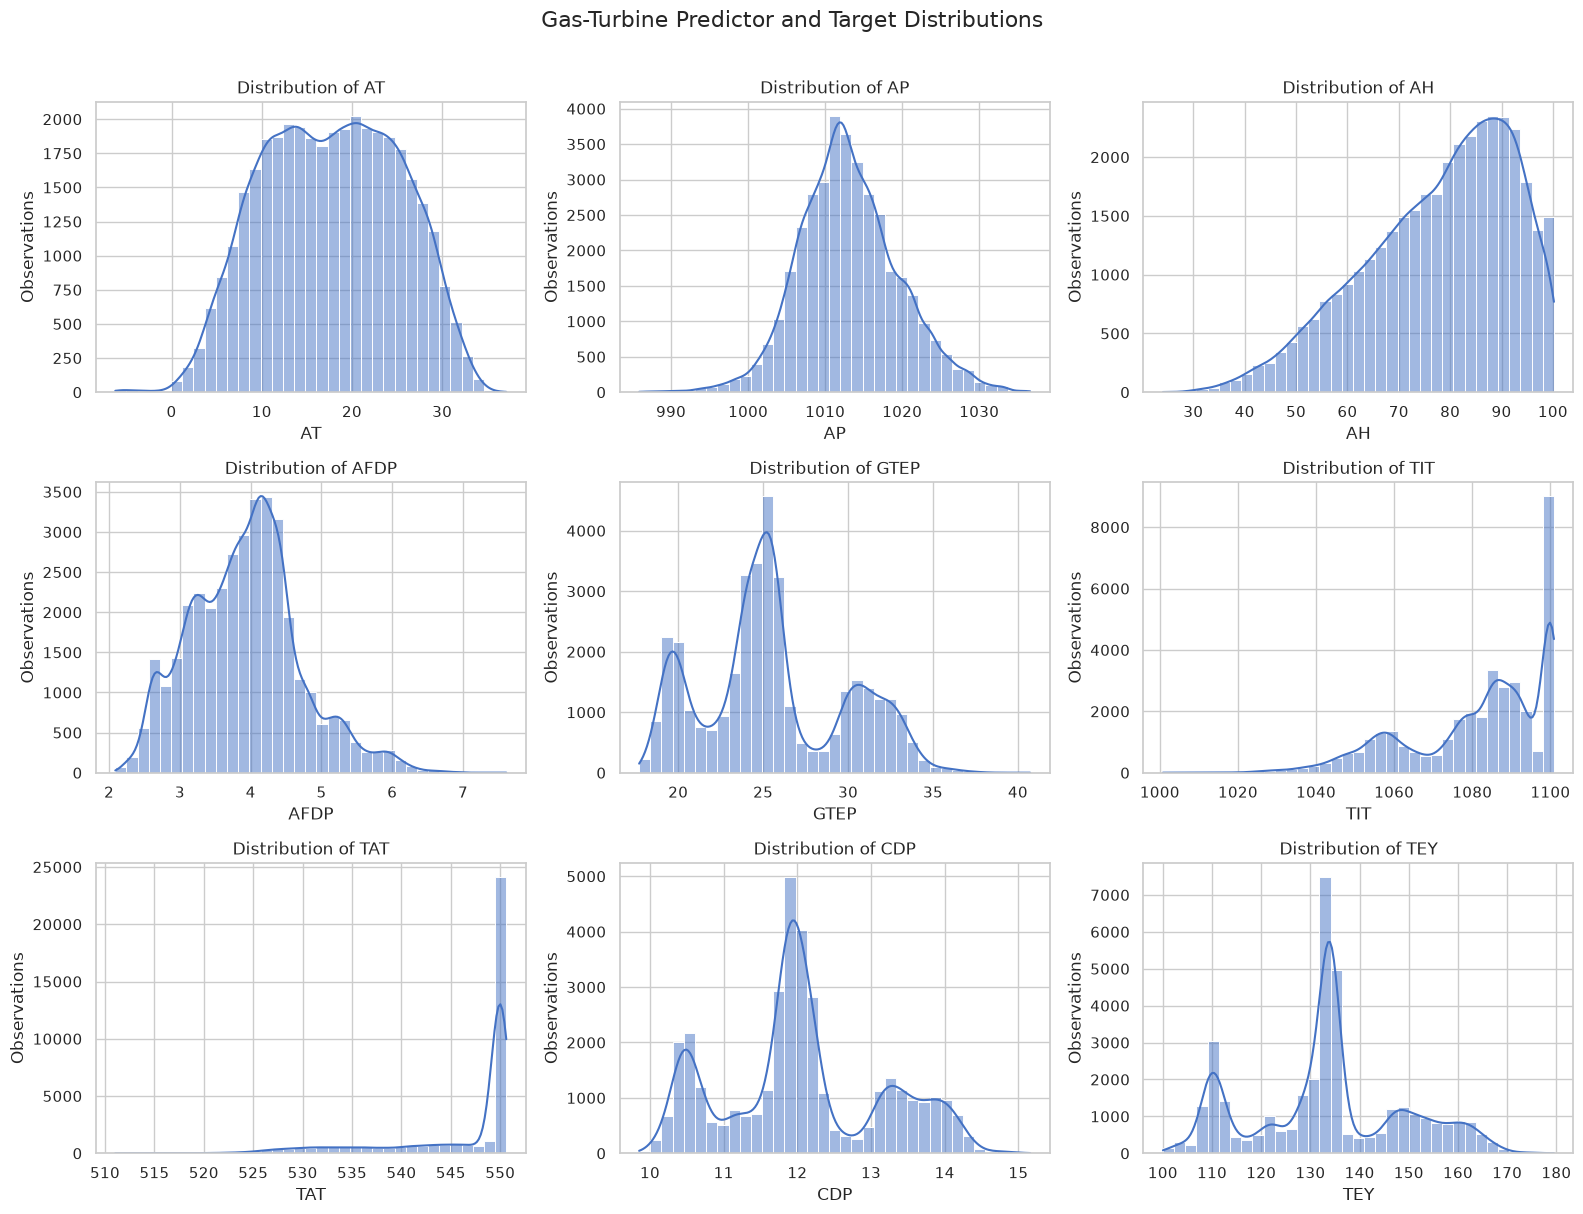

In [5]:
plot_columns = RAW_FEATURES + [TARGET]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for axis, column in zip(axes.flat, plot_columns, strict=True):
    sns.histplot(raw[column], bins=35, kde=True, ax=axis, color="#4472C4")
    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel(column)
    axis.set_ylabel("Observations")
fig.suptitle("Gas-Turbine Predictor and Target Distributions", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Observation:** `TEY` is approximately symmetric, whereas several operating variables contain distinct concentrations and bounded regimes rather than normal bell shapes. Those shapes are plausible for a controlled machine operating at repeated settings; they should not be deleted merely because a generic outlier rule flags them.

## 5. Correlation structure

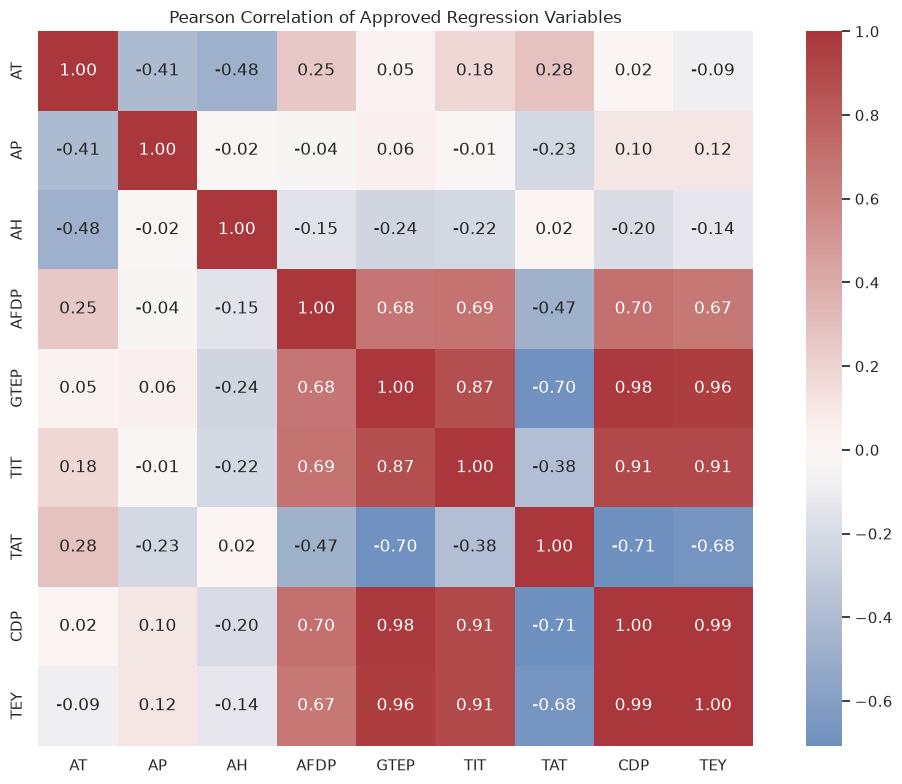

,correlation_with_TEY
CDP,0.9888
GTEP,0.9641
TIT,0.9103
TAT,-0.6824
AFDP,0.6655
AH,-0.1374
AP,0.1182
AT,-0.0912


In [6]:
corr = raw[RAW_FEATURES + [TARGET]].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Pearson Correlation of Approved Regression Variables")
plt.tight_layout()
plt.show()

display(corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False).to_frame("correlation_with_TEY"))

**Observation:** `CDP`, `GTEP`, and `TIT` have the strongest linear association with energy yield, and several predictors are strongly associated with one another. The final task must therefore be described as contemporaneous soft-sensor estimation. Regularised models and coefficient interpretation will need to acknowledge multicollinearity rather than treating correlated coefficients as causal effects.

## 6. Feature-target relationships and temporal context

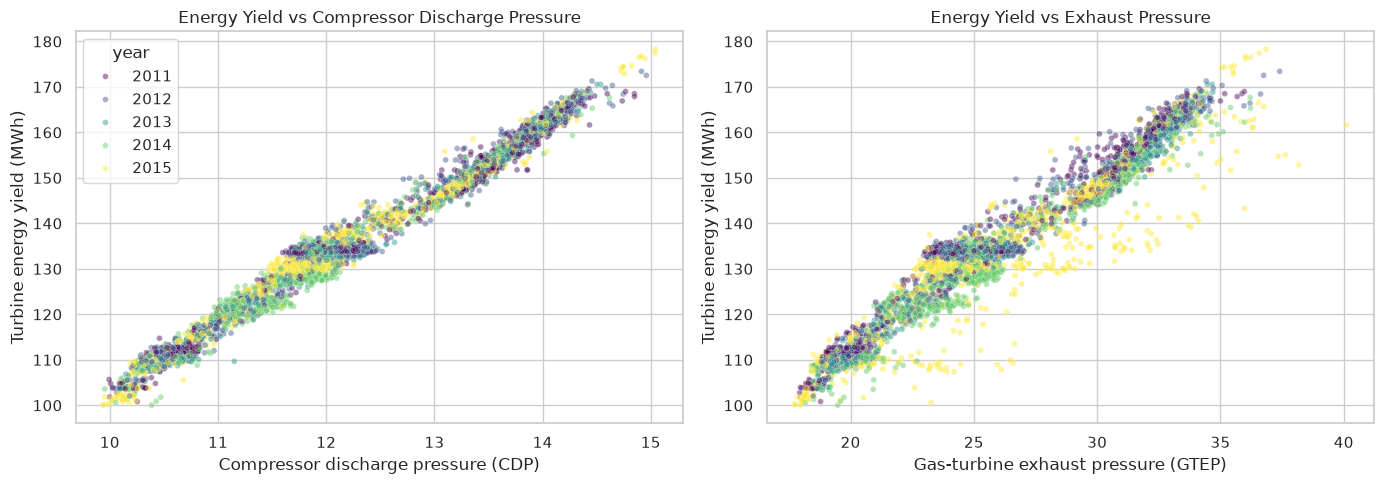

In [7]:
sample = raw.sample(n=min(6_000, len(raw)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=sample, x="CDP", y=TARGET, hue="year", palette="viridis", alpha=0.45, s=18, ax=axes[0])
axes[0].set_title("Energy Yield vs Compressor Discharge Pressure")
axes[0].set_xlabel("Compressor discharge pressure (CDP)")
axes[0].set_ylabel("Turbine energy yield (MWh)")
sns.scatterplot(data=sample, x="GTEP", y=TARGET, hue="year", palette="viridis", alpha=0.45, s=18, ax=axes[1], legend=False)
axes[1].set_title("Energy Yield vs Exhaust Pressure")
axes[1].set_xlabel("Gas-turbine exhaust pressure (GTEP)")
axes[1].set_ylabel("Turbine energy yield (MWh)")
plt.tight_layout()
plt.show()

**Observation:** Both pressure measurements have strong, mostly monotonic relationships with `TEY`, but the visible width around each trend leaves room for multivariate models. Colouring by year also shows that all years occupy broadly similar regions while retaining enough temporal structure to justify a held-out 2015 test.

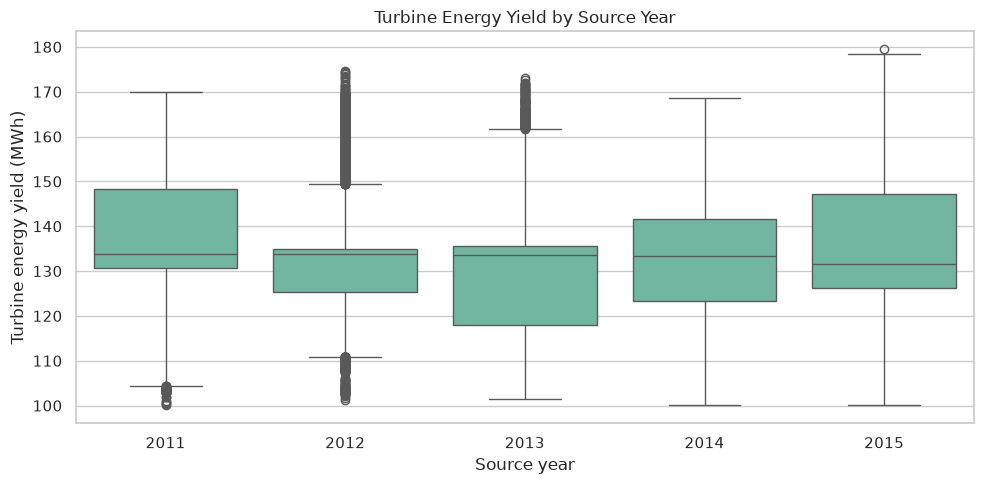

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=raw, x="year", y=TARGET, color="#66C2A5")
plt.title("Turbine Energy Yield by Source Year")
plt.xlabel("Source year")
plt.ylabel("Turbine energy yield (MWh)")
plt.tight_layout()
plt.show()

**Observation:** The annual distributions overlap, but their centres and ranges are not identical. Holding out 2015 tests whether relationships learned from 2011-2014 remain useful in a later operating period instead of benefiting from a random mixture of every year.

## 7. Outlier audit

In [9]:
def iqr_audit(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    records = []
    for column in columns:
        q1, q3 = frame[column].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flagged = frame[column].lt(lower) | frame[column].gt(upper)
        records.append(
            {
                "feature": column,
                "lower_fence": lower,
                "upper_fence": upper,
                "flagged_rows": int(flagged.sum()),
                "flagged_share_pct": 100 * flagged.mean(),
                "observed_min": frame[column].min(),
                "observed_max": frame[column].max(),
            }
        )
    return pd.DataFrame(records).set_index("feature")

outlier_audit = iqr_audit(raw, RAW_FEATURES + [TARGET])
display(outlier_audit)

,lower_fence,upper_fence,flagged_rows,flagged_share_pct,observed_min,observed_max
feature,,,,,,
AT,-6.0450,41.4910,1,0.0027,-6.2348,37.1030
AP,996.5000,"1,029.3000",612,1.6661,985.8500,"1,036.6000"
AH,36.4060,121.1580,132,0.3593,24.0850,100.2000
AFDP,1.8236,5.9089,557,1.5163,2.0874,7.6106
GTEP,14.2310,37.9590,7,0.0191,17.6980,40.7160
TIT,"1,034.0000","1,134.8000",315,0.8575,"1,000.8000","1,100.9000"
TAT,536.7400,558.0200,4955,13.4892,511.0400,550.6100
CDP,9.3050,14.9850,10,0.0272,9.8518,15.1590
TEY,95.0050,173.5250,33,0.0898,100.0200,179.5000


**Decision:** No row is removed solely by the 1.5-IQR heuristic. In particular, `TAT` has many flagged values because its distribution is concentrated near an upper operating range, not because thousands of readings are invalid. Observed values remain within the source dataset's operating ranges. Scaling and model-specific robustness will be handled inside training pipelines in Phase 3.

## 8. Cleaning and deterministic feature engineering

In [10]:
clean = (
    raw.sort_values(["year", "source_row"])
    .drop_duplicates(subset=duplicate_subset, keep="first")
    .reset_index(drop=True)
)
assert len(raw) - len(clean) == 7
assert clean[RAW_FEATURES + [TARGET]].isna().sum().sum() == 0

def add_regression_features(frame: pd.DataFrame) -> pd.DataFrame:
    # Row-wise features that are also computable for unseen observations.
    engineered = frame.copy()
    engineered["temperature_drop"] = engineered["TIT"] - engineered["TAT"]
    engineered["exhaust_to_discharge_pressure"] = np.divide(
        engineered["GTEP"],
        engineered["CDP"],
        out=np.full(len(engineered), np.nan, dtype=float),
        where=engineered["CDP"].to_numpy() != 0,
    )
    engineered["ambient_heat_load"] = engineered["AT"] * engineered["AH"]
    return engineered

model_data = add_regression_features(clean)
ENGINEERED_FEATURES = [
    "temperature_drop",
    "exhaust_to_discharge_pressure",
    "ambient_heat_load",
]
MODEL_FEATURES = RAW_FEATURES + ENGINEERED_FEATURES

print(f"Rows before cleaning: {len(raw):,}")
print(f"Rows after duplicate removal: {len(model_data):,}")
display(model_data[ENGINEERED_FEATURES].describe().T)

Rows before cleaning: 36,733
Rows after duplicate removal: 36,726


,count,mean,std,min,25%,50%,75%,max
temperature_drop,"36,726.0000",535.2691,21.1139,483.2600,522.0500,536.0200,550.7875,586.9100
exhaust_to_discharge_pressure,"36,726.0000",2.1063,0.1645,1.7148,2.0007,2.0964,2.2487,2.8637
ambient_heat_load,"36,726.0000","1,327.7671",502.8245,-417.7092,966.8585,"1,354.9327","1,712.2455","2,539.1938"


**Justification:** `temperature_drop` represents the thermal change across the turbine, the pressure ratio normalises exhaust pressure by compressor discharge pressure, and `ambient_heat_load` represents a temperature-humidity interaction. All three use only same-row approved measurements and can be recomputed for unseen data. They are candidates, not guaranteed improvements; Phase 3 must compare them using training-only cross-validation.

## 9. Chronological train/test split

In [11]:
train_mask = model_data["year"].le(2014)
test_mask = model_data["year"].eq(2015)
assert train_mask.any() and test_mask.any() and not (train_mask & test_mask).any()

X_train = model_data.loc[train_mask, MODEL_FEATURES].copy()
y_train = model_data.loc[train_mask, TARGET].copy()
X_test = model_data.loc[test_mask, MODEL_FEATURES].copy()
y_test = model_data.loc[test_mask, TARGET].copy()

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "share_pct": [100 * len(X_train) / len(model_data), 100 * len(X_test) / len(model_data)],
        "TEY_mean": [y_train.mean(), y_test.mean()],
        "TEY_std": [y_train.std(), y_test.std()],
        "first_year": [model_data.loc[train_mask, "year"].min(), model_data.loc[test_mask, "year"].min()],
        "last_year": [model_data.loc[train_mask, "year"].max(), model_data.loc[test_mask, "year"].max()],
    },
    index=["training_and_CV", "final_test"],
)
display(split_summary)
assert len(X_train) == 29_342 and len(X_test) == 7_384

,rows,share_pct,TEY_mean,TEY_std,first_year,last_year
training_and_CV,29342,79.8944,133.3834,15.4734,2011,2014
final_test,7384,20.1056,133.9934,16.1792,2015,2015


**Decision:** Training and model selection use 2011-2014; the untouched final test is 2015. The seven removed duplicates were all in 2014, leaving 29,342 training rows and 7,384 test rows. The test set must not be used for feature selection, hyperparameter tuning, or model ranking during Phase 3.

## 10. Leakage-safe preprocessing contract

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

regression_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# This fit is a protocol validation only. Phase 3 must place a fresh clone of this
# preprocessor inside every model pipeline so each CV fold learns its own statistics.
X_train_prepared = regression_preprocessor.fit_transform(X_train)
X_test_prepared = regression_preprocessor.transform(X_test)

print(f"Prepared training shape: {X_train_prepared.shape}")
print(f"Prepared test shape: {X_test_prepared.shape}")
print(f"Finite training values: {np.isfinite(X_train_prepared).all()}")
print(f"Finite test values: {np.isfinite(X_test_prepared).all()}")

Prepared training shape: (29342, 11)
Prepared test shape: (7384, 11)
Finite training values: True
Finite test values: True


**Decision:** Median imputation remains inside the pipeline even though the present files have no missing values, making the protocol safe if an unseen record is incomplete. Standardisation is required for SVR, KNN, and regularised linear models and does not change the information available to tree models. Every Phase 3 estimator must receive a fresh pipeline so preprocessing is fitted separately inside each cross-validation fold.

In [13]:
time_cv = TimeSeriesSplit(n_splits=5)
years_train = model_data.loc[train_mask, "year"].reset_index(drop=True)
fold_records = []
for fold, (fit_idx, validation_idx) in enumerate(time_cv.split(X_train), start=1):
    fold_records.append(
        {
            "fold": fold,
            "fit_rows": len(fit_idx),
            "validation_rows": len(validation_idx),
            "fit_first_year": int(years_train.iloc[fit_idx].min()),
            "fit_last_year": int(years_train.iloc[fit_idx].max()),
            "validation_first_year": int(years_train.iloc[validation_idx].min()),
            "validation_last_year": int(years_train.iloc[validation_idx].max()),
            "ordered": bool(fit_idx.max() < validation_idx.min()),
        }
    )
fold_summary = pd.DataFrame(fold_records).set_index("fold")
display(fold_summary)
assert fold_summary["ordered"].all()

,fit_rows,validation_rows,fit_first_year,fit_last_year,validation_first_year,validation_last_year,ordered
fold,,,,,,,
1,4892,4890,2011,2011,2011,2012,True
2,9782,4890,2011,2012,2012,2012,True
3,14672,4890,2011,2012,2012,2013,True
4,19562,4890,2011,2013,2013,2014,True
5,24452,4890,2011,2014,2014,2014,True


**Cross-validation contract:** Five expanding-window folds preserve row order within 2011-2014. The final 2015 observations remain outside every fold. Because exact timestamps are unavailable, this is a year-and-source-order protocol rather than a claim about equally spaced hourly time-series forecasting.

## 11. Phase 2 regression handoff

Phase 3 must reuse `MODEL_FEATURES`, the fixed 2011-2014/2015 split, and the five-fold `TimeSeriesSplit`. It must compare all ten required algorithms, tune only inside the training period, and regenerate every final metric and diagnostic from the executed notebook. The three engineered features must be retained only if training-only evidence supports them.

# Phase 3 - Regression Modeling and Evaluation

Phase 3 trains every required regressor on the fixed 2011-2014 training period. Hyperparameters and feature choices are selected only through the five ordered training folds. The untouched 2015 test set is used once for the final comparison after all searches are complete.

> **Team verification gate:** The team must rerun this notebook, verify every displayed value and interpretation, and be prepared to explain each estimator and hyperparameter during the viva.

## 12. Training-only engineered-feature decision

In [14]:
from copy import deepcopy
from time import perf_counter

from IPython.display import Markdown
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

def make_regression_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", clone(regression_preprocessor)),
            ("model", model),
        ]
    )

raw_train = model_data.loc[train_mask, RAW_FEATURES].copy()
engineered_train = model_data.loc[train_mask, RAW_FEATURES + ENGINEERED_FEATURES].copy()
feature_cv_rows = []
for feature_set, frame in {
    "Approved raw features": raw_train,
    "Raw + three engineered features": engineered_train,
}.items():
    estimator = make_regression_pipeline(LinearRegression())
    scores = cross_val_score(
        estimator,
        frame,
        y_train,
        cv=time_cv,
        scoring="r2",
        n_jobs=-1,
    )
    feature_cv_rows.append(
        {
            "Feature set": feature_set,
            "Mean CV R2": scores.mean(),
            "Std CV R2": scores.std(),
            "Fold R2": np.round(scores, 6).tolist(),
        }
    )

feature_selection_results = (
    pd.DataFrame(feature_cv_rows)
    .sort_values("Mean CV R2", ascending=False)
    .reset_index(drop=True)
)
display(feature_selection_results)

use_engineered_features = (
    feature_selection_results.iloc[0]["Feature set"]
    == "Raw + three engineered features"
)
REGRESSION_MODEL_FEATURES = (
    RAW_FEATURES + ENGINEERED_FEATURES if use_engineered_features else RAW_FEATURES
)
X_train_model = model_data.loc[train_mask, REGRESSION_MODEL_FEATURES].copy()
X_test_model = model_data.loc[test_mask, REGRESSION_MODEL_FEATURES].copy()

display(
    Markdown(
        f"**Decision:** `{feature_selection_results.iloc[0]['Feature set']}` is retained "
        f"because its mean five-fold training R2 is "
        f"`{feature_selection_results.iloc[0]['Mean CV R2']:.6f}` versus "
        f"`{feature_selection_results.iloc[1]['Mean CV R2']:.6f}`. "
        "The difference is small, so Phase 3 treats the engineered variables as modest "
        "supporting features rather than the source of the model's performance."
    )
)

,Feature set,Mean CV R2,Std CV R2,Fold R2
0,Raw + three engineered features,0.9870,0.0191,"[0.997289, 0.997145, 0.997534, 0.948975, 0.994..."
1,Approved raw features,0.9867,0.0200,"[0.997439, 0.997147, 0.997486, 0.94679, 0.994545]"


**Decision:** `Raw + three engineered features` is retained because its mean five-fold training R2 is `0.987017` versus `0.986681`. The difference is small, so Phase 3 treats the engineered variables as modest supporting features rather than the source of the model's performance.

## 13. Shared training and search helpers

Every estimator uses the same training rows, target, feature set, preprocessing steps, and ordered cross-validation object. Search scoring is R². `GridSearchCV(refit=True)` refits the chosen configuration on all 2011-2014 rows only.

In [15]:
regression_estimators = {}
regression_cv_records = []
regression_search_records = []

def register_fixed_regressor(name, estimator):
    started = perf_counter()
    scores = cross_val_score(
        estimator,
        X_train_model,
        y_train,
        cv=time_cv,
        scoring="r2",
        n_jobs=-1,
        error_score="raise",
    )
    estimator.fit(X_train_model, y_train)
    elapsed = perf_counter() - started
    regression_estimators[name] = estimator
    regression_cv_records.append(
        {
            "Model": name,
            "CV Mean R2": scores.mean(),
            "CV Std R2": scores.std(),
            "Search Seconds": elapsed,
        }
    )
    regression_search_records.append(
        {"Model": name, "Best Parameters": "Fixed baseline", "Candidates": 1}
    )
    print(f"Completed {name} in {elapsed:.1f}s")

def register_searched_regressor(name, estimator, parameter_grid):
    started = perf_counter()
    search = GridSearchCV(
        estimator=estimator,
        param_grid=parameter_grid,
        scoring="r2",
        cv=time_cv,
        n_jobs=-1,
        refit=True,
        error_score="raise",
        return_train_score=False,
    )
    search.fit(X_train_model, y_train)
    elapsed = perf_counter() - started
    regression_estimators[name] = search.best_estimator_
    regression_cv_records.append(
        {
            "Model": name,
            "CV Mean R2": search.best_score_,
            "CV Std R2": search.cv_results_["std_test_score"][search.best_index_],
            "Search Seconds": elapsed,
        }
    )
    regression_search_records.append(
        {
            "Model": name,
            "Best Parameters": search.best_params_,
            "Candidates": len(search.cv_results_["params"]),
        }
    )
    print(f"Completed {name} in {elapsed:.1f}s | {search.best_params_}")

## 14. Algorithms 1-5 - linear and polynomial family

In [16]:
register_fixed_regressor(
    "Linear Regression",
    make_regression_pipeline(LinearRegression()),
)

register_searched_regressor(
    "Ridge Regression",
    make_regression_pipeline(Ridge()),
    {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
)

register_searched_regressor(
    "Lasso Regression",
    make_regression_pipeline(Lasso(max_iter=100_000, tol=1e-3, random_state=RANDOM_STATE)),
    {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]},
)

register_searched_regressor(
    "ElasticNet Regression",
    make_regression_pipeline(
        ElasticNet(max_iter=100_000, tol=1e-3, random_state=RANDOM_STATE)
    ),
    {
        "model__alpha": [0.001, 0.01, 0.1],
        "model__l1_ratio": [0.2, 0.5, 0.8],
    },
)

polynomial_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("polynomial", PolynomialFeatures(include_bias=False)),
        ("model", LinearRegression()),
    ]
)
register_searched_regressor(
    "Polynomial Regression",
    polynomial_pipeline,
    {"polynomial__degree": [1, 2]},
)

Completed Linear Regression in 1.2s


Completed Ridge Regression in 1.4s | {'model__alpha': 100.0}


Completed Lasso Regression in 1.7s | {'model__alpha': 0.1}


Completed ElasticNet Regression in 0.8s | {'model__alpha': 0.1, 'model__l1_ratio': 0.8}


Completed Polynomial Regression in 0.4s | {'polynomial__degree': 1}


In [17]:
linear_family_cv = (
    pd.DataFrame(regression_cv_records)
    .sort_values("CV Mean R2", ascending=False)
    .reset_index(drop=True)
)
linear_family_parameters = pd.DataFrame(regression_search_records)
display(linear_family_cv.style.format({
    "CV Mean R2": "{:.6f}",
    "CV Std R2": "{:.6f}",
    "Search Seconds": "{:.1f}",
}))
display(linear_family_parameters)

,Model,CV Mean R2,CV Std R2,Search Seconds
0,ElasticNet Regression,0.993347,0.003728,0.8
1,Ridge Regression,0.992484,0.006887,1.4
2,Lasso Regression,0.991100,0.010269,1.7
3,Linear Regression,0.987017,0.019061,1.2
4,Polynomial Regression,0.987017,0.019061,0.4


,Model,Best Parameters,Candidates
0,Linear Regression,Fixed baseline,1
1,Ridge Regression,{'model__alpha': 100.0},5
2,Lasso Regression,{'model__alpha': 0.1},5
3,ElasticNet Regression,"{'model__alpha': 0.1, 'model__l1_ratio': 0.8}",9
4,Polynomial Regression,{'polynomial__degree': 1},2


**Interpretation:** Linear Regression is the unregularised reference. Ridge shrinks correlated coefficients without forcing them to zero; Lasso may create sparsity; ElasticNet combines both penalties. Polynomial Regression tests whether pairwise interactions and squared terms improve time-aware validation rather than assuming that extra complexity is beneficial.

In [18]:
linear_coefficients = pd.Series(
    regression_estimators["Linear Regression"].named_steps["model"].coef_,
    index=REGRESSION_MODEL_FEATURES,
    name="standardised_coefficient",
).sort_values(key=np.abs, ascending=False)
display(linear_coefficients.to_frame())

lasso_coefficients = pd.Series(
    regression_estimators["Lasso Regression"].named_steps["model"].coef_,
    index=REGRESSION_MODEL_FEATURES,
    name="lasso_coefficient",
)
lasso_zero_count = int(np.isclose(lasso_coefficients, 0.0, atol=1e-10).sum())
lasso_sparsity = pd.DataFrame(
    {
        "zero_coefficients": [lasso_zero_count],
        "nonzero_coefficients": [len(lasso_coefficients) - lasso_zero_count],
        "total_coefficients": [len(lasso_coefficients)],
    }
)
display(lasso_sparsity)
display(lasso_coefficients.sort_values(key=np.abs, ascending=False).to_frame())

,standardised_coefficient
CDP,11.6311
exhaust_to_discharge_pressure,3.1029
AT,-2.6021
GTEP,-2.5189
TIT,2.0574
temperature_drop,1.5651
TAT,0.3291
AP,-0.2833
AFDP,-0.0844
AH,-0.0466


,zero_coefficients,nonzero_coefficients,total_coefficients
0,5,6,11


,lasso_coefficient
CDP,7.4411
GTEP,4.5221
TIT,3.5265
AT,-2.4346
AP,-0.0839
ambient_heat_load,-0.0083
AH,0.0000
TAT,-0.0000
AFDP,0.0000
temperature_drop,0.0000


**Coefficient caution:** Coefficients describe a one-standard-deviation change while other transformed variables are held fixed. Strong multicollinearity among `CDP`, `GTEP`, `TIT`, and engineered pressure/temperature features can redistribute coefficient magnitude, so these values are predictive associations rather than isolated physical effects.

## 15. Algorithms 6-10 - nonlinear, ensemble, kernel, and distance models

In [19]:
register_searched_regressor(
    "Decision Tree Regressor",
    make_regression_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    {
        "model__max_depth": [6, 10, None],
        "model__min_samples_leaf": [1, 10],
    },
)

register_searched_regressor(
    "Random Forest Regressor",
    make_regression_pipeline(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
    ),
    {
        "model__n_estimators": [100, 200],
        "model__max_depth": [12, None],
        "model__min_samples_leaf": [1],
    },
)

register_searched_regressor(
    "Gradient Boosting Regressor",
    make_regression_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2],
    },
)

register_searched_regressor(
    "Support Vector Regressor",
    make_regression_pipeline(SVR(cache_size=2_000)),
    {
        "model__C": [0.1, 1.0],
        "model__kernel": ["linear", "rbf"],
        "model__epsilon": [0.1],
    },
)

register_searched_regressor(
    "K-Nearest Neighbors Regressor",
    make_regression_pipeline(KNeighborsRegressor()),
    {
        "model__n_neighbors": [3, 7, 15],
        "model__weights": ["uniform", "distance"],
        "model__p": [2],
    },
)

Completed Decision Tree Regressor in 1.1s | {'model__max_depth': None, 'model__min_samples_leaf': 1}


Completed Random Forest Regressor in 80.1s | {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}


Completed Gradient Boosting Regressor in 27.8s | {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}


Completed Support Vector Regressor in 58.0s | {'model__C': 0.1, 'model__epsilon': 0.1, 'model__kernel': 'linear'}


Completed K-Nearest Neighbors Regressor in 0.6s | {'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'distance'}


## 16. Hyperparameter search evidence

In [20]:
regression_cv_table = (
    pd.DataFrame(regression_cv_records)
    .sort_values("CV Mean R2", ascending=False)
    .reset_index(drop=True)
)
regression_parameter_table = pd.DataFrame(regression_search_records)
display(regression_cv_table.style.format({
    "CV Mean R2": "{:.6f}",
    "CV Std R2": "{:.6f}",
    "Search Seconds": "{:.1f}",
}))
display(regression_parameter_table)

,Model,CV Mean R2,CV Std R2,Search Seconds
0,ElasticNet Regression,0.993347,0.003728,0.8
1,Ridge Regression,0.992484,0.006887,1.4
2,Lasso Regression,0.991100,0.010269,1.7
3,Support Vector Regressor,0.988028,0.016703,58.0
4,Linear Regression,0.987017,0.019061,1.2
5,Polynomial Regression,0.987017,0.019061,0.4
6,K-Nearest Neighbors Regressor,0.986367,0.003414,0.6
7,Gradient Boosting Regressor,0.986048,0.014416,27.8
8,Random Forest Regressor,0.985772,0.017594,80.1
9,Decision Tree Regressor,0.982356,0.016092,1.1


,Model,Best Parameters,Candidates
0,Linear Regression,Fixed baseline,1
1,Ridge Regression,{'model__alpha': 100.0},5
2,Lasso Regression,{'model__alpha': 0.1},5
3,ElasticNet Regression,"{'model__alpha': 0.1, 'model__l1_ratio': 0.8}",9
4,Polynomial Regression,{'polynomial__degree': 1},2
5,Decision Tree Regressor,"{'model__max_depth': None, 'model__min_samples...",6
6,Random Forest Regressor,"{'model__max_depth': None, 'model__min_samples...",4
7,Gradient Boosting Regressor,"{'model__learning_rate': 0.1, 'model__max_dept...",4
8,Support Vector Regressor,"{'model__C': 0.1, 'model__epsilon': 0.1, 'mode...",4
9,K-Nearest Neighbors Regressor,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",6


The parameter table is the audit trail for every required algorithm-specific choice: Ridge/Lasso `alpha`, ElasticNet `alpha` and `l1_ratio`, polynomial degree, tree depth, forest size and depth, boosting learning rate and estimator count, SVR `C` and kernel, and KNN neighborhood size and weighting.

In [21]:
formal_tuning_rows = []
default_tuning_models = {
    "Ridge Regression": make_regression_pipeline(Ridge()),
    "Lasso Regression": make_regression_pipeline(
        Lasso(max_iter=100_000, tol=1e-3, random_state=RANDOM_STATE)
    ),
    "Random Forest Regressor": make_regression_pipeline(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
    ),
    "Gradient Boosting Regressor": make_regression_pipeline(
        GradientBoostingRegressor(random_state=RANDOM_STATE)
    ),
}
for name, default_estimator in default_tuning_models.items():
    default_scores = cross_val_score(
        default_estimator,
        X_train_model,
        y_train,
        cv=time_cv,
        scoring="r2",
        n_jobs=-1,
        error_score="raise",
    )
    tuned_row = regression_cv_table.set_index("Model").loc[name]
    best_params = regression_parameter_table.set_index("Model").loc[name, "Best Parameters"]
    formal_tuning_rows.append(
        {
            "Model": name,
            "Default CV R2": default_scores.mean(),
            "Tuned CV R2": tuned_row["CV Mean R2"],
            "CV R2 Improvement": tuned_row["CV Mean R2"] - default_scores.mean(),
            "Best Parameters": best_params,
        }
    )
formal_tuning_summary = pd.DataFrame(formal_tuning_rows)
display(formal_tuning_summary.style.format({
    "Default CV R2": "{:.6f}",
    "Tuned CV R2": "{:.6f}",
    "CV R2 Improvement": "{:+.6f}",
}))

,Model,Default CV R2,Tuned CV R2,CV R2 Improvement,Best Parameters
0,Ridge Regression,0.987314,0.992484,+0.005170,{'model__alpha': 100.0}
1,Lasso Regression,0.980745,0.991100,+0.010354,{'model__alpha': 0.1}
2,Random Forest Regressor,0.985772,0.985772,+0.000000,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}"
3,Gradient Boosting Regressor,0.985571,0.986048,+0.000478,"{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}"


**Tuning interpretation:** Improvement is measured only on the ordered training folds. A negative or very small difference is still informative: the default may already be close to optimal, and the search result should not be replaced using 2015 performance.

## 17. Final held-out comparison of all ten models

In [22]:
regression_test_predictions = {}
test_metric_rows = []
for name, estimator in regression_estimators.items():
    predictions = estimator.predict(X_test_model)
    regression_test_predictions[name] = predictions
    test_metric_rows.append(
        {
            "Model": name,
            "Test R2": r2_score(y_test, predictions),
            "Test RMSE (MWh)": mean_squared_error(y_test, predictions) ** 0.5,
            "Test MAE (MWh)": mean_absolute_error(y_test, predictions),
        }
    )

regression_comparison = (
    pd.DataFrame(test_metric_rows)
    .merge(regression_cv_table.drop(columns="Search Seconds"), on="Model", how="left")
    .sort_values("Test R2", ascending=False)
    .reset_index(drop=True)
)
display(regression_comparison.style.format({
    "Test R2": "{:.6f}",
    "Test RMSE (MWh)": "{:.4f}",
    "Test MAE (MWh)": "{:.4f}",
    "CV Mean R2": "{:.6f}",
    "CV Std R2": "{:.6f}",
}))

,Model,Test R2,Test RMSE (MWh),Test MAE (MWh),CV Mean R2,CV Std R2
0,Random Forest Regressor,0.995106,1.1318,0.8536,0.985772,0.017594
1,Gradient Boosting Regressor,0.993269,1.3273,1.0387,0.986048,0.014416
2,Decision Tree Regressor,0.990595,1.5690,1.2080,0.982356,0.016092
3,Lasso Regression,0.986571,1.8748,1.3323,0.991100,0.010269
4,Polynomial Regression,0.985659,1.9374,1.3694,0.987017,0.019061
5,Linear Regression,0.985659,1.9374,1.3694,0.987017,0.019061
6,Ridge Regression,0.979901,2.2936,1.6377,0.992484,0.006887
7,Support Vector Regressor,0.976770,2.4657,1.6511,0.988028,0.016703
8,ElasticNet Regression,0.968555,2.8688,2.0224,0.993347,0.003728
9,K-Nearest Neighbors Regressor,0.960324,3.2225,2.2300,0.986367,0.003414


**Comparison rule:** All ten rows use the same 7,384 observations from 2015. The table is sorted by test R² for rubric readability, but the final model was already selected by mean training CV R² before this table was inspected.

## 18. Five-fold R2 for the two training-CV leaders

In [23]:
top_two_names = regression_cv_table.head(2)["Model"].tolist()
top_two_fold_rows = []
for name in top_two_names:
    fold_scores = cross_val_score(
        clone(regression_estimators[name]),
        X_train_model,
        y_train,
        cv=time_cv,
        scoring="r2",
        n_jobs=-1,
        error_score="raise",
    )
    record = {"Model": name, "Mean CV R2": fold_scores.mean(), "Std CV R2": fold_scores.std()}
    record.update({f"Fold {index} R2": value for index, value in enumerate(fold_scores, start=1)})
    top_two_fold_rows.append(record)
top_two_cv_results = pd.DataFrame(top_two_fold_rows)
display(top_two_cv_results.style.format({column: "{:.6f}" for column in top_two_cv_results.columns if "R2" in column}))

FINAL_REGRESSION_MODEL_NAME = top_two_names[0]
final_regression_estimator = regression_estimators[FINAL_REGRESSION_MODEL_NAME]
final_regression_predictions = regression_test_predictions[FINAL_REGRESSION_MODEL_NAME]
HELDOUT_LEADER_NAME = regression_comparison.iloc[0]["Model"]
print(f"Final model selected by training CV: {FINAL_REGRESSION_MODEL_NAME}")
print(f"Highest held-out 2015 R2: {HELDOUT_LEADER_NAME}")

,Model,Mean CV R2,Std CV R2,Fold 1 R2,Fold 2 R2,Fold 3 R2,Fold 4 R2,Fold 5 R2
0,ElasticNet Regression,0.993347,0.003728,0.996279,0.993850,0.997608,0.986963,0.992037
1,Ridge Regression,0.992484,0.006887,0.996754,0.996353,0.996843,0.978925,0.993545


Final model selected by training CV: ElasticNet Regression
Highest held-out 2015 R2: Random Forest Regressor


## 19. Tree-based feature importance

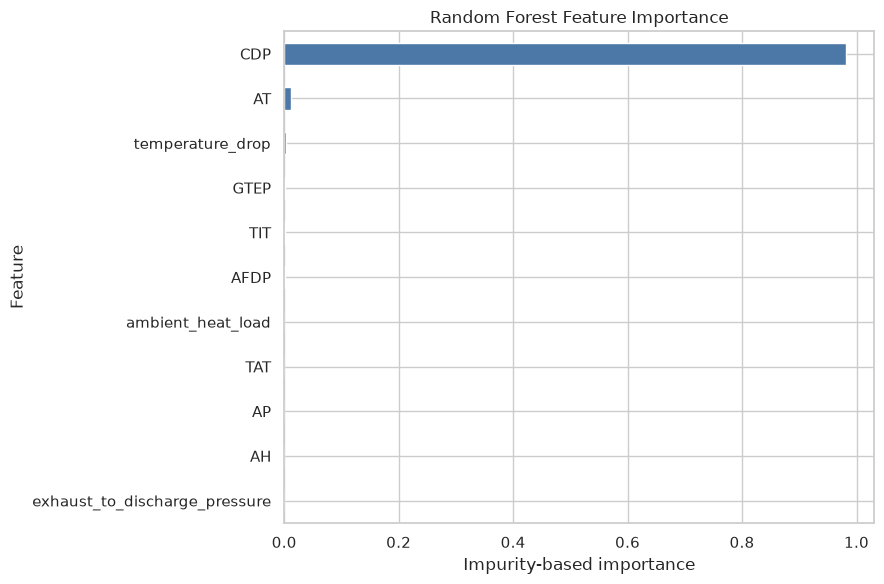

,importance
CDP,0.9815
AT,0.0113
temperature_drop,0.0033
GTEP,0.0011
TIT,0.0009
AFDP,0.0005
ambient_heat_load,0.0004
TAT,0.0004
AP,0.0003
AH,0.0002


In [24]:
forest_model = regression_estimators["Random Forest Regressor"].named_steps["model"]
forest_importance = (
    pd.Series(
        forest_model.feature_importances_,
        index=REGRESSION_MODEL_FEATURES,
        name="importance",
    )
    .sort_values(ascending=True)
)
plt.figure(figsize=(9, 6))
forest_importance.plot(kind="barh", color="#4C78A8")
plt.title("Random Forest Feature Importance")
plt.xlabel("Impurity-based importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
display(forest_importance.sort_values(ascending=False).to_frame())

**Interpretation:** Impurity importance identifies the measurements most used by the fitted forest, not causal drivers. Correlated pressure and temperature variables can divide or mask one another's importance, so the ranking should be read together with the correlation audit.

## 20. Final-model diagnostics

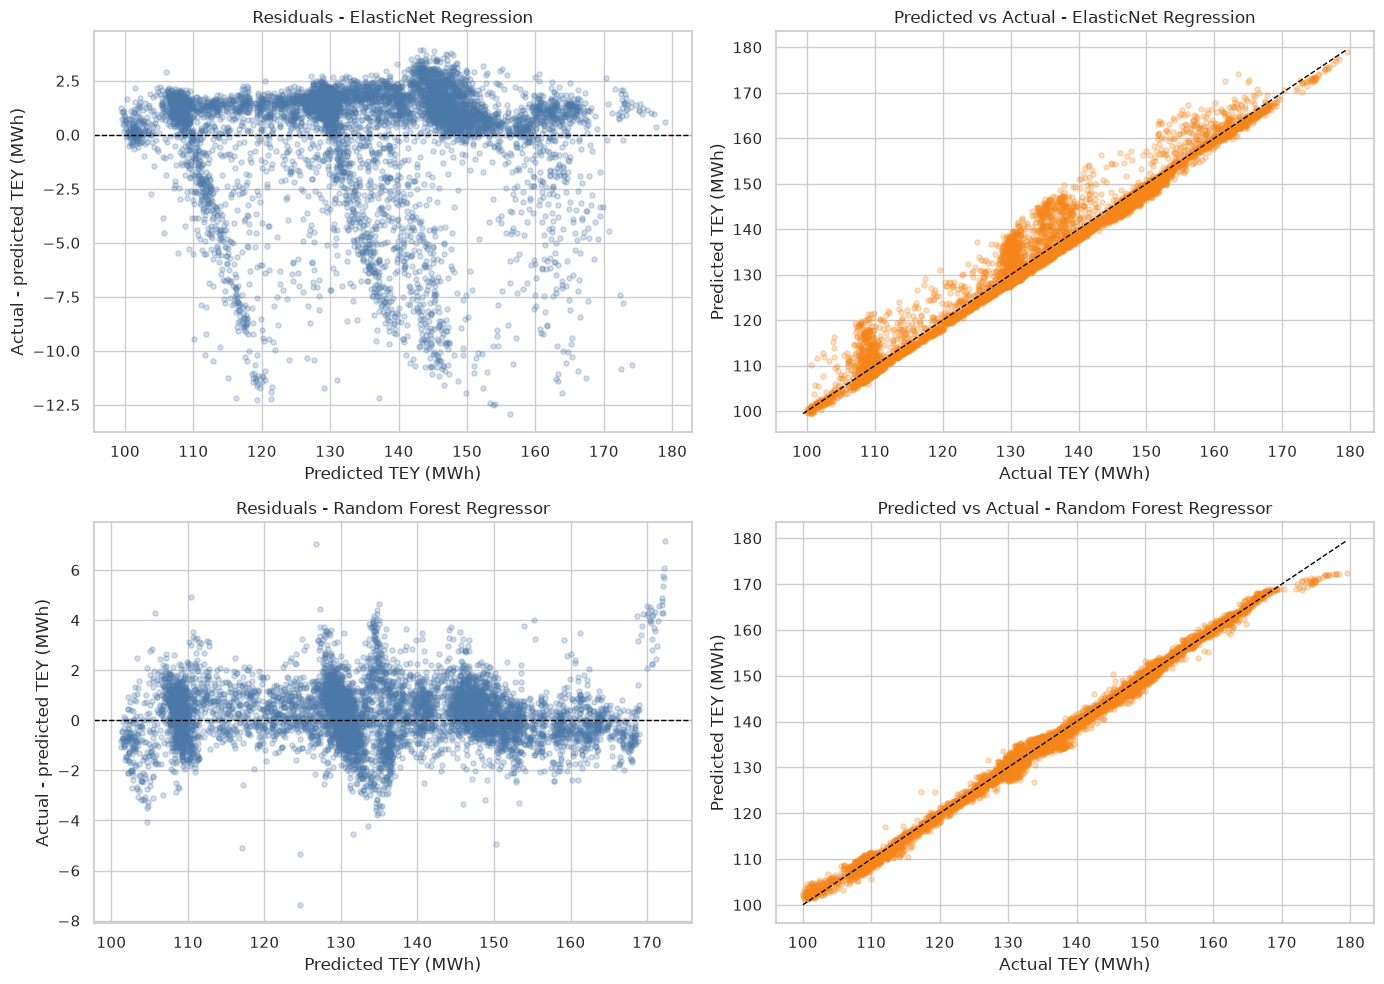

,Model,Residual mean (MWh),Residual std (MWh),Residual median (MWh)
0,ElasticNet Regression,0.0402,2.8688,1.1132
1,Random Forest Regressor,0.2384,1.1065,0.2462


In [25]:
diagnostic_models = list(dict.fromkeys([FINAL_REGRESSION_MODEL_NAME, HELDOUT_LEADER_NAME]))
fig, axes = plt.subplots(len(diagnostic_models), 2, figsize=(14, 5 * len(diagnostic_models)), squeeze=False)
residual_summary_rows = []
for row_index, name in enumerate(diagnostic_models):
    predictions = regression_test_predictions[name]
    residuals = y_test.to_numpy() - predictions

    axes[row_index, 0].scatter(predictions, residuals, alpha=0.25, s=14, color="#4C78A8")
    axes[row_index, 0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[row_index, 0].set_title(f"Residuals - {name}")
    axes[row_index, 0].set_xlabel("Predicted TEY (MWh)")
    axes[row_index, 0].set_ylabel("Actual - predicted TEY (MWh)")

    axes[row_index, 1].scatter(y_test, predictions, alpha=0.25, s=14, color="#F58518")
    lower = min(y_test.min(), predictions.min())
    upper = max(y_test.max(), predictions.max())
    axes[row_index, 1].plot([lower, upper], [lower, upper], color="black", linestyle="--", linewidth=1)
    axes[row_index, 1].set_title(f"Predicted vs Actual - {name}")
    axes[row_index, 1].set_xlabel("Actual TEY (MWh)")
    axes[row_index, 1].set_ylabel("Predicted TEY (MWh)")

    residual_summary_rows.append(
        {
            "Model": name,
            "Residual mean (MWh)": residuals.mean(),
            "Residual std (MWh)": residuals.std(ddof=1),
            "Residual median (MWh)": np.median(residuals),
        }
    )

plt.tight_layout()
plt.show()
residual_summary = pd.DataFrame(residual_summary_rows)
display(residual_summary)

In [26]:
final_cv_row = regression_cv_table.set_index("Model").loc[FINAL_REGRESSION_MODEL_NAME]
final_test_row = regression_comparison.set_index("Model").loc[FINAL_REGRESSION_MODEL_NAME]
heldout_leader_row = regression_comparison.set_index("Model").loc[HELDOUT_LEADER_NAME]
display(
    Markdown(
        f"**Final regression conclusion:** `{FINAL_REGRESSION_MODEL_NAME}` was preselected "
        f"from training data with mean five-fold R2 `{final_cv_row['CV Mean R2']:.6f}` "
        f"(SD `{final_cv_row['CV Std R2']:.6f}`). On the untouched 2015 test year it "
        f"achieved R2 `{final_test_row['Test R2']:.6f}`, RMSE "
        f"`{final_test_row['Test RMSE (MWh)']:.4f} MWh`, and MAE "
        f"`{final_test_row['Test MAE (MWh)']:.4f} MWh`. `{HELDOUT_LEADER_NAME}` produced "
        f"the highest descriptive 2015 R2 (`{heldout_leader_row['Test R2']:.6f}`) with RMSE "
        f"`{heldout_leader_row['Test RMSE (MWh)']:.4f} MWh`. This disagreement signals "
        "year-to-year validation instability; 2015 was not used to retroactively change parameters. "
        "Diagnostics are shown for both models and must be checked for systematic residual structure."
    )
)

**Final regression conclusion:** `ElasticNet Regression` was preselected from training data with mean five-fold R2 `0.993347` (SD `0.003728`). On the untouched 2015 test year it achieved R2 `0.968555`, RMSE `2.8688 MWh`, and MAE `2.0224 MWh`. `Random Forest Regressor` produced the highest descriptive 2015 R2 (`0.995106`) with RMSE `1.1318 MWh`. This disagreement signals year-to-year validation instability; 2015 was not used to retroactively change parameters. Diagnostics are shown for both models and must be checked for systematic residual structure.

## 21. Exported regression evidence

In [27]:
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
regression_comparison.to_csv(RESULTS_DIR / "regression_model_comparison.csv", index=False)
regression_parameter_table.to_csv(RESULTS_DIR / "regression_best_parameters.csv", index=False)
top_two_cv_results.to_csv(RESULTS_DIR / "regression_top2_cv.csv", index=False)
formal_tuning_summary.to_csv(RESULTS_DIR / "regression_tuning_summary.csv", index=False)
print("Exported four regression result tables to results/.")

Exported four regression result tables to results/.


## 22. Regression limitations and handoff

- The source represents one turbine at one plant; external performance is unknown.
- Exact timestamps are unavailable, so the temporal protocol relies on source-year and row order.
- Strong contemporaneous measurements make this a soft sensor, not a long-range forecast.
- Impurity importance and coefficients are associations affected by correlated inputs.
- The team must validate the engineered-feature decision and all written interpretations before presentation.